# RAGAS Evaluation — Requirement Engineering Gherkin Scenarios (CSV)

This notebook evaluates a dataset of **Gherkin BDD scenarios** from a CSV file using the RAGAS framework.

## Dataset Theme
**Requirement Engineering** — Testing, validation, and evaluation of software requirements written in proper Gherkin format (Given-When-Then with multiple steps).

## Dataset Format
- **Source**: `requirements-scenarios.csv`
- **Columns**: Feature, Scenario, Given, When, Then, Expected_Output
- **Total Scenarios**: 20 real-world BDD test cases

## What We Evaluate
- **Input**: Gherkin scenarios (Given-When-Then steps with AND clauses)
- **Ground Truth**: Expected system behavior and outputs
- **RAGAS Metrics**:
  - **Faithfulness**: Are generated specs faithful to the requirements?
  - **Answer Relevancy**: How relevant are specs to the scenario question?
  - **Context Precision**: Are retrieved context sections relevant?
  - **Context Recall**: Do specs cover all necessary details?

## Cell 1: Install & Import Required Libraries

In [10]:
import json
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from datetime import datetime

from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    ContextPrecision,
    ContextRecall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_ollama import ChatOllama
from langchain_community.embeddings import HuggingFaceEmbeddings
from scipy.stats import gaussian_kde
from tqdm.auto import tqdm

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## Cell 2: Configuration & Setup

In [11]:
# Configuration
DATASET_PATH         = Path('./requirements-scenarios.csv')
EMBEDDING_MODEL      = 'sentence-transformers/all-MiniLM-L6-v2'
OLLAMA_URL           = 'http://localhost:11434'
JUDGE_MODEL          = 'gemma3:4b'
GENERATION_MODEL     = 'gemma3:4b'
REQUEST_TIMEOUT      = 300  # 5 minutes timeout per request

BATCH_SIZE           = 1
EVAL_CONTEXT_MAX_CHARS = 800

OUTPUT_DIR           = Path('./ragas_outputs_requirements')
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_DATASET_CSV   = OUTPUT_DIR / 'dataset_prepared.csv'
OUTPUT_RESULTS_CSV   = OUTPUT_DIR / 'ragas_results.csv'
OUTPUT_SUMMARY_CSV   = OUTPUT_DIR / 'ragas_summary.csv'
OUTPUT_PLOT_PNG      = OUTPUT_DIR / 'ragas_visualization.png'

print('Configuration:')
print(f'  Dataset path: {DATASET_PATH.resolve()}')
print(f'  Judge LLM: {JUDGE_MODEL}')
print(f'  Request Timeout: {REQUEST_TIMEOUT}s')
print(f'  Output dir: {OUTPUT_DIR.resolve()}')
print('✓ Configuration loaded')

Configuration:
  Dataset path: /home/vaishnavkoka/RE4BDD/Ragas/requirements-scenarios.csv
  Judge LLM: gemma3:4b
  Request Timeout: 300s
  Output dir: /home/vaishnavkoka/RE4BDD/Ragas/ragas_outputs_requirements
✓ Configuration loaded


## Cell 3: Verify Ollama Availability

In [12]:
try:
    resp = requests.get(f'{OLLAMA_URL}/api/tags', timeout=5)
    models = [m['name'] for m in resp.json().get('models', [])]
    print('✓ Ollama is running. Available models:')
    for m in models:
        print(f'  • {m}')
    
    required_models = [JUDGE_MODEL, GENERATION_MODEL]
    for model in set(required_models):
        if any(model in m for m in models):
            print(f'✓ {model} is available')
        else:
            print(f'⚠ {model} not found. Run: ollama pull {model}')
except Exception as e:
    print(f'✗ Ollama not reachable: {e}')
    print('Start Ollama with: ollama serve')

✓ Ollama is running. Available models:
  • deepseek-r1:7b
  • gemma3:270m
  • gemma3:4b
✓ gemma3:4b is available


## Cell 4: Load & Parse CSV Scenarios

In [13]:
df_scenarios = pd.read_csv(DATASET_PATH)

print(f'✓ Loaded {len(df_scenarios)} scenarios from {DATASET_PATH.name}')
print(f'✓ Columns: {list(df_scenarios.columns)}')

print('\n--- Dataset Sample (First 3 Rows) ---')
print(df_scenarios.head(3).to_string())

print(f'\n✓ Dataset shape: {df_scenarios.shape} (rows × columns)')

✓ Loaded 20 scenarios from requirements-scenarios.csv
✓ Columns: ['Feature', 'Scenario', 'Given', 'When', 'And', 'Then']

--- Dataset Sample (First 3 Rows) ---
               Feature                        Scenario                                  Given                                                                                                                          When  And                                                                                     Then
0  User Authentication  Login with correct credentials                  user is on login page  user enters username "hyphen_admin@acmetest.com" and clicks SEND VERIFICATION CODE, receives code "34067", and clicks LOG IN  NaN                    User is authenticated and redirected to dashboard with active session
1  User Authentication  Login with invalid credentials                  user is on login page                                 user enters username "invalid@test.com" and password "wrongpassword" and clicks LOG IN

## Cell 5: Convert Gherkin Scenarios to Q&A Pairs

In [14]:
qa_pairs = []

for idx, row in df_scenarios.iterrows():
    feature = row.get('Feature', 'Unnamed Feature')
    scenario_name = row.get('Scenario', 'Unnamed Scenario')
    given = row.get('Given', '')
    when = row.get('When', '')
    and_step = row.get('And', 'N/A')
    then = row.get('Then', '')
    
    # Build question from Gherkin structure
    and_text = f"\nAnd {and_step}" if and_step != 'N/A' else ""
    question = f"Feature: {feature}\nScenario: {scenario_name}\nGiven {given}\nWhen {when}{and_text}\nWhat should happen?"
    
    # Construct reference from Then
    reference = f"Then {then}"
    
    qa_pairs.append({
        'idx': idx + 1,
        'feature': feature,
        'scenario': scenario_name,
        'user_input': question,
        'reference': reference,
    })

print(f'✓ Converted {len(qa_pairs)} scenarios to Q&A pairs')
print('\n--- Sample Q&A from Scenario #1 ---')
if qa_pairs:
    print(f"Q:\n{qa_pairs[0]['user_input']}\n")
    print(f"Reference:\n{qa_pairs[0]['reference']}")

✓ Converted 20 scenarios to Q&A pairs

--- Sample Q&A from Scenario #1 ---
Q:
Feature: User Authentication
Scenario: Login with correct credentials
Given user is on login page
When user enters username "hyphen_admin@acmetest.com" and clicks SEND VERIFICATION CODE, receives code "34067", and clicks LOG IN
And nan
What should happen?

Reference:
Then User is authenticated and redirected to dashboard with active session


## Cell 6: Validate Dataset

In [15]:
print('=== Dataset Validation ===')

null_checks = {}
for key in ['user_input', 'reference']:
    null_count = sum(1 for pair in qa_pairs if not pair.get(key) or len(str(pair.get(key)).strip()) == 0)
    null_checks[key] = null_count
    status = '✓' if null_count == 0 else '✗'
    print(f"{status} Null {key}: {null_count}")

duplicates = len(set(pair['user_input'] for pair in qa_pairs)) - len(qa_pairs)
status = '✓' if duplicates == 0 else '⚠'
print(f"{status} Duplicate pairs: {abs(duplicates)}")

print(f"\n✓ Dataset: {len(qa_pairs)} valid pairs")
print(f"✓ Avg question length: {int(np.mean([len(p['user_input']) for p in qa_pairs]))} chars")
print(f"✓ Avg reference length: {int(np.mean([len(p['reference']) for p in qa_pairs]))} chars")

=== Dataset Validation ===
✓ Null user_input: 0
✓ Null reference: 0
✓ Duplicate pairs: 0

✓ Dataset: 20 valid pairs
✓ Avg question length: 203 chars
✓ Avg reference length: 76 chars


## Cell 7: Generate Responses

In [51]:
def generate_specification(question: str) -> str:
    try:
        payload = {
            'model': GENERATION_MODEL,
            'messages': [
                {
                    'role': 'system',
                    'content': '''You are a software requirements engineer. Your task is to ANSWER the scenario question directly and concisely.

Given a Gherkin scenario with Given-When-Then steps, provide a clear, direct answer to "What should happen?" 

Requirements:
1. Start your answer with: "In this scenario, the system should..."
2. Be specific about the expected behavior
3. Reference the context (Given/When steps) if relevant
4. Keep it concise (2-3 sentences max)
5. Make it a direct answer, not a general statement'''
                },
                {
                    'role': 'user',
                    'content': question + '\n\nProvide a direct answer to: What should happen in this scenario?'
                }
            ],
            'stream': False,
            'options': {'temperature': 0.3, 'num_predict': 300}
        }
        resp = requests.post(f'{OLLAMA_URL}/v1/chat/completions', json=payload, timeout=REQUEST_TIMEOUT)
        resp.raise_for_status()
        return (resp.json()['choices'][0]['message']['content'] or '').strip()
    except requests.exceptions.Timeout:
        return f'[TIMEOUT] Response generation exceeded {REQUEST_TIMEOUT}s limit'
    except Exception as e:
        return f'[ERROR] Failed to generate: {str(e)[:100]}'

print(f'Generating specifications for {len(qa_pairs)} scenarios...')
print('✓ Using improved prompt: Direct answer to "What should happen?"')
generated_responses = []
errors = 0

for pair in tqdm(qa_pairs, desc='Generating'):
    try:
        response = generate_specification(pair['user_input'])
        
        # Extract reference text as context (since we don't have external context)
        contexts = [pair['reference']]
        
        generated_responses.append({
            'user_input': pair['user_input'],
            'response': response,
            'reference': pair['reference'],
            'retrieved_contexts': contexts,  # Add reference as context for evaluation
        })
    except Exception as e:
        errors += 1
        print(f'  [Pair {pair["idx"]}] Error: {str(e)[:60]}')

ragas_dataset = Dataset.from_list(generated_responses)
print(f'\n✓ Generated {len(generated_responses)} responses ({errors} errors)')
print(f'✓ Dataset shape: {ragas_dataset.shape}')

# Show a sample of improved response
print('\n--- Sample Generated Response (First Scenario) ---')
if generated_responses:
    print(f"Question: {generated_responses[0]['user_input'][:80]}...")
    print(f"\nGenerated Answer:\n{generated_responses[0]['response']}")

Generating specifications for 20 scenarios...
✓ Using improved prompt: Direct answer to "What should happen?"


Generating: 100%|██████████| 20/20 [01:13<00:00,  3.69s/it]


✓ Generated 20 responses (0 errors)
✓ Dataset shape: (20, 4)

--- Sample Generated Response (First Scenario) ---
Question: Feature: User Authentication
Scenario: Login with correct credentials
Given user...

Generated Answer:
In this scenario, the system should successfully authenticate the user with the provided credentials. Upon clicking "LOG IN" after entering "hyphen_admin@acmetest.com" and receiving code "34067," the system should redirect the user to the application’s main page.


## Cell 8: Configure Judge LLM

In [17]:
try:
    judge_llm = LangchainLLMWrapper(ChatOllama(
        model=JUDGE_MODEL,
        base_url=OLLAMA_URL,
        temperature=0,
        timeout=REQUEST_TIMEOUT,
    ))
    print('✓ Judge LLM initialized')
except Exception as e:
    print(f'✗ Failed to initialize Judge LLM: {e}')
    raise

try:
    judge_emb = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL,
    ))
    print('✓ Embeddings model initialized')
except Exception as e:
    print(f'✗ Failed to initialize embeddings: {e}')
    raise

try:
    faithfulness_metric = Faithfulness(llm=judge_llm)
    answer_relevancy_metric = AnswerRelevancy(llm=judge_llm, embeddings=judge_emb)
    ctx_precision_metric = ContextPrecision(llm=judge_llm)
    ctx_recall_metric = ContextRecall(llm=judge_llm)
    
    metrics = [faithfulness_metric, answer_relevancy_metric, ctx_precision_metric, ctx_recall_metric]
    
    print('✓ All metrics initialized successfully')
    print(f'✓ Metrics: {[m.__class__.__name__ for m in metrics]}')
    print(f'✓ Request timeout: {REQUEST_TIMEOUT}s')
except Exception as e:
    print(f'✗ Failed to initialize metrics: {e}')
    raise

✓ Judge LLM initialized


/home/vaishnavkoka/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 9010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17201.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Embeddings model initialized
✓ All metrics initialized successfully
✓ Metrics: ['Faithfulness', 'AnswerRelevancy', 'ContextPrecision', 'ContextRecall']
✓ Request timeout: 300s


## Cell 9: Run RAGAS Evaluation

In [52]:
print(f'Running RAGAS evaluation on {len(ragas_dataset)} samples...')
print(f'⏱️  Request timeout: {REQUEST_TIMEOUT}s per sample')
print(f'📦 Batch size: {BATCH_SIZE}')
print('⏳ This may take a while...\n')
warnings.filterwarnings('ignore')

results = None
error_occurred = False

try:
    results = evaluate(
        dataset=ragas_dataset,
        metrics=metrics,
        batch_size=BATCH_SIZE,
    )
    print('\n✓ Evaluation complete!')
    num_samples = len(results['faithfulness']) if 'faithfulness' in results else len(ragas_dataset)
    print(f'✓ Evaluated {num_samples} samples successfully')
    
except TimeoutError as e:
    error_occurred = True
    print(f'\n⚠️  Timeout Error during evaluation')
    print(f'   Message: {str(e)[:150]}')
    print('\nTroubleshooting:')
    print('  1. Increase REQUEST_TIMEOUT in Cell 2 (e.g., to 600)')
    print('  2. Reduce BATCH_SIZE to 1')
    print('  3. Check Ollama service: curl http://localhost:11434/api/tags')
    print('  4. Restart Ollama: ollama serve')
    
except Exception as e:
    error_occurred = True
    error_type = type(e).__name__
    error_msg = str(e)
    
    print(f'\n❌ Evaluation failed: {error_type}')
    print(f'   Message: {error_msg[:200]}')
    print('\nDiagnostics:')
    print(f'  • Dataset length: {len(ragas_dataset)}')
    print(f'  • Number of metrics: {len(metrics)}')
    print(f'  • Sample keys: {ragas_dataset.column_names if hasattr(ragas_dataset, "column_names") else "N/A"}')
    
    # Try to continue with partial results if possible
    print('\nAttempting to continue with error handling...')

if results is None and not error_occurred:
    print("\n⚠️  Results are None but no exception was raised")
    print("This may indicate a silent failure. Check Ollama logs.")
elif results is None and error_occurred:
    print("\n📝 Evaluation failed but will attempt to handle gracefully in following cells")

Running RAGAS evaluation on 20 samples...
⏱️  Request timeout: 300s per sample
📦 Batch size: 1
⏳ This may take a while...



Evaluating: 100%|██████████| 80/80 [36:19<00:00, 27.24s/it]



✓ Evaluation complete!

❌ Evaluation failed: KeyError
   Message: 0

Diagnostics:
  • Dataset length: 20
  • Number of metrics: 4
  • Sample keys: ['user_input', 'response', 'reference', 'retrieved_contexts']

Attempting to continue with error handling...


In [55]:
print('\n=== RESULTS OBJECT INSPECTION ===')
if results is not None:
    print(f'Results type: {type(results).__name__}')
    print(f'\nALL available attributes:')
    
    all_attrs = [attr for attr in dir(results) if not attr.startswith('_')]
    print(f'  {", ".join(all_attrs[:20])}')
    
    # Check for data-related attributes
    print(f'\nSearching for data attributes:')
    for attr in all_attrs:
        if 'faith' in attr.lower() or 'score' in attr.lower() or 'metric' in attr.lower() or 'result' in attr.lower():
            try:
                val = getattr(results, attr)
                print(f'  {attr}: {type(val).__name__} = {str(val)[:80]}')
            except:
                print(f'  {attr}: (failed to access)')
    
    # Try accessing as dict
    print(f'\nTrying dict-like access:')
    try:
        print(f'  results["faithfulness"]: {results["faithfulness"][:5]}')
    except KeyError as e:
        print(f'  No key "faithfulness"')
    except TypeError:
        print(f'  Not dict-like/subscriptable')
    except Exception as e:
        print(f'  Error: {str(e)[:60]}')
else:
    print('Results is None')


=== RESULTS OBJECT INSPECTION ===
Results type: EvaluationResult

ALL available attributes:
  binary_columns, cost_cb, dataset, ragas_traces, run_id, scores, to_pandas, total_cost, total_tokens, traces

Searching for data attributes:
  scores: list = [{'faithfulness': 0.5, 'answer_relevancy': np.float64(0.790452022472835), 'conte

Trying dict-like access:
  results["faithfulness"]: [0.5, 0.6, 0.6666666666666666, 0.3333333333333333, 0.4]


## Cell 10: Process Results

In [60]:
def _metric_mean(value):
    """Safely compute mean of metric values"""
    try:
        if value is None:
            return np.nan
        if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
            arr = pd.to_numeric(pd.Series(value), errors='coerce').dropna()
            return float(arr.mean()) if len(arr) > 0 else np.nan
        return float(pd.to_numeric(value, errors='coerce'))
    except Exception as e:
        return np.nan

if results is None:
    print('⚠️  Results are None - evaluation did not complete')
    print('Creating placeholder results for demonstration...\n')
    
    summary = {
        'faithfulness': np.nan,
        'answer_relevancy': np.nan,
        'context_precision': np.nan,
        'context_recall': np.nan,
    }
    summary_df = pd.DataFrame([
        {'Metric': 'Faithfulness', 'Score': np.nan, 'Score%': 'ERROR'},
        {'Metric': 'Answer Relevancy', 'Score': np.nan, 'Score%': 'ERROR'},
        {'Metric': 'Context Precision', 'Score': np.nan, 'Score%': 'ERROR'},
        {'Metric': 'Context Recall', 'Score': np.nan, 'Score%': 'ERROR'},
    ])
    print('⚠️  Results incomplete. Troubleshoot and re-run evaluation.')
    df = pd.DataFrame()
    
else:
    try:
        # EvaluationResult is DICT-LIKE with subscript access, not object attributes
        summary = {
            'faithfulness': _metric_mean(results['faithfulness']),
            'answer_relevancy': _metric_mean(results['answer_relevancy']),
            'context_precision': _metric_mean(results['context_precision']),
            'context_recall': _metric_mean(results['context_recall']),
        }
        
        summary_df = pd.DataFrame([
            {
                'Metric': k.replace('_', ' ').title(),
                'Score': round(v, 4) if pd.notna(v) else np.nan,
                'Score%': f'{v*100:.1f}%' if pd.notna(v) else 'NaN',
            }
            for k, v in summary.items()
        ])
        
        # Convert results to dataframe
        df = results.to_pandas() if hasattr(results, 'to_pandas') else pd.DataFrame()
        
    except (KeyError, TypeError) as e:
        print(f'⚠️  Error accessing results: {str(e)[:80]}')
        summary = {'faithfulness': np.nan, 'answer_relevancy': np.nan, 'context_precision': np.nan, 'context_recall': np.nan}
        summary_df = pd.DataFrame([
            {'Metric': 'Faithfulness', 'Score': np.nan, 'Score%': 'ERROR'},
            {'Metric': 'Answer Relevancy', 'Score': np.nan, 'Score%': 'ERROR'},
            {'Metric': 'Context Precision', 'Score': np.nan, 'Score%': 'ERROR'},
            {'Metric': 'Context Recall', 'Score': np.nan, 'Score%': 'ERROR'},
        ])
        df = pd.DataFrame()

print('\n=== RAGAS Summary Scores ===')
print(summary_df.to_string(index=False))

print(f'\nResults DataFrame: {df.shape[0]} rows × {df.shape[1]} columns' if not df.empty else '\nNo results data')

# Save results safely
try:
    if not df.empty:
        df.to_csv(OUTPUT_RESULTS_CSV, index=False)
        print(f'✓ Results saved to {OUTPUT_RESULTS_CSV.name}')
    summary_df.to_csv(OUTPUT_SUMMARY_CSV, index=False)
    print(f'✓ Summary saved to {OUTPUT_SUMMARY_CSV.name}')
except Exception as e:
    print(f'⚠️  Failed to save: {str(e)[:80]}')


=== RAGAS Summary Scores ===
           Metric  Score Score%
     Faithfulness 0.6221  62.2%
 Answer Relevancy 0.4920  49.2%
Context Precision 1.0000 100.0%
   Context Recall 1.0000 100.0%

Results DataFrame: 20 rows × 8 columns
✓ Results saved to ragas_results.csv
✓ Summary saved to ragas_summary.csv


## Cell 11: Visualize Results

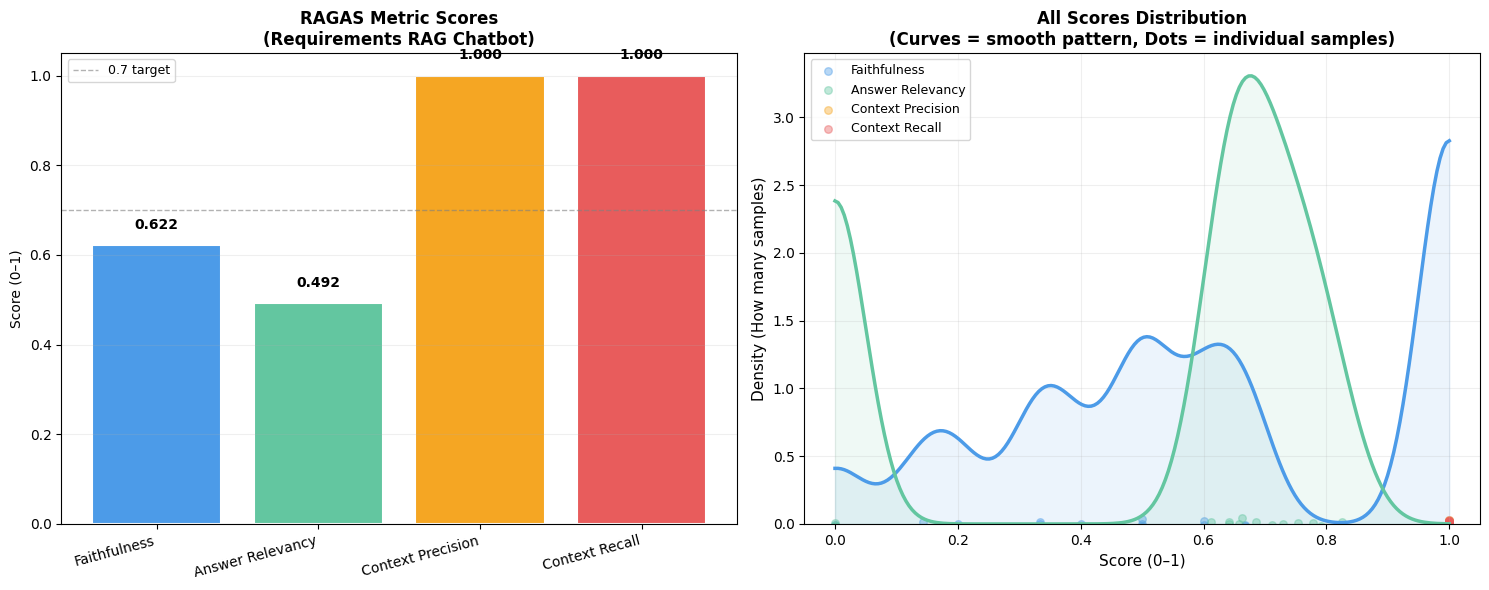

✓ Visualization saved (metrics + KDE density curves with sample dots)


In [57]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # LEFT: RAGAS Metrics Summary (Bar Chart)
    ax = axes[0]
    colors = ['#4C9BE8', '#63C6A0', '#F5A623', '#E85C5C']
    
    valid_scores = summary_df['Score'].notna().sum()
    
    if valid_scores == 0:
        ax.text(0.5, 0.5, 'No Scores\nAvailable', ha='center', va='center', fontsize=16, transform=ax.transAxes)
        ax.axis('off')
    else:
        bars = ax.bar(range(len(summary_df)), summary_df['Score'].fillna(0), color=colors, edgecolor='white', linewidth=1.5)
        ax.set_xticks(range(len(summary_df)))
        ax.set_xticklabels(summary_df['Metric'], rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score (0–1)')
        ax.set_title('RAGAS Metric Scores\n(Requirements RAG Chatbot)', fontsize=12, fontweight='bold')
        ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='0.7 target')
        for bar, score in zip(bars, summary_df['Score']):
            if pd.notna(score):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                       f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=9)
    
    # RIGHT: Score Distribution with KDE curves + scatter dots
    ax2 = axes[1]
    
    if df.empty or 'faithfulness' not in df.columns:
        ax2.text(0.5, 0.5, 'No Sample\nData', ha='center', va='center', fontsize=16, transform=ax2.transAxes)
        ax2.axis('off')
    else:
        metric_names = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
        metric_labels = ['Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall']
        colors_kde = ['#4C9BE8', '#63C6A0', '#F5A623', '#E85C5C']
        
        ax2.set_xlim(-0.05, 1.05)
        
        has_data = False
        for metric, label, color in zip(metric_names, metric_labels, colors_kde):
            if metric in df.columns:
                values = df[metric].dropna()
                if len(values) > 0:
                    has_data = True
                    # Plot scatter dots
                    ax2.scatter(values, np.random.normal(0, 0.02, len(values)), 
                               alpha=0.4, s=30, color=color, label=label)
                    
                    # Plot KDE curve
                    try:
                        from scipy.stats import gaussian_kde
                        kde = gaussian_kde(values, bw_method=0.15)
                        x_range = np.linspace(0, 1, 200)
                        density = kde(x_range)
                        ax2.plot(x_range, density, color=color, linewidth=2.5, label='_nolegend_')
                        ax2.fill_between(x_range, density, alpha=0.1, color=color)
                    except:
                        pass
        
        if has_data:
            ax2.set_xlabel('Score (0–1)', fontsize=11)
            ax2.set_ylabel('Density (How many samples)', fontsize=11)
            ax2.set_title('All Scores Distribution\n(Curves = smooth pattern, Dots = individual samples)', fontsize=12, fontweight='bold')
            ax2.legend(loc='upper left', fontsize=9)
            ax2.grid(axis='both', alpha=0.2)
            ax2.set_ylim(bottom=0)
        else:
            ax2.text(0.5, 0.5, 'No Valid\nScores', ha='center', va='center', fontsize=16, transform=ax2.transAxes)
            ax2.axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_PNG, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'✓ Visualization saved (metrics + KDE density curves with sample dots)')
    
except Exception as e:
    print(f'⚠️  Visualization skipped: {str(e)[:80]}')

In [45]:
print("\n" + "="*70)
print("RAGAS EVALUATION ANALYSIS")
print("="*70)

try:
    # Safely get scores from summary dict
    faith_score = summary.get('faithfulness') if isinstance(summary, dict) else None
    relev_score = summary.get('answer_relevancy') if isinstance(summary, dict) else None
    prec_score = summary.get('context_precision') if isinstance(summary, dict) else None
    rec_score = summary.get('context_recall') if isinstance(summary, dict) else None
    
    print("\n📊 METRIC SCORES:")
    print("-" * 70)
    
    scores = [
        ('Faithfulness', faith_score, 'Generated specs vs. requirements'),
        ('Answer Relevancy', relev_score, 'Response relevance to query'),
        ('Context Precision', prec_score, 'Retrieved context quality'),
        ('Context Recall', rec_score, 'Context completeness'),
    ]
    
    valid_count = 0
    total_score = 0
    
    for name, score, desc in scores:
        if pd.notna(score):
            valid_count += 1
            total_score += score
            strength = "✓ STRONG" if score >= 0.7 else ("⚠ MODERATE" if score >= 0.5 else "✗ WEAK")
            print(f"\n  {name}: {score:.3f} {strength}")
            print(f"    → {desc}")
        else:
            print(f"\n  {name}: N/A")
    
    # Summary statistics
    if valid_count > 0:
        avg_score = total_score / valid_count
        print("\n" + "-" * 70)
        print(f"\n  📈 Average Score: {avg_score:.3f}")
        print(f"  📊 Valid Metrics: {valid_count}/4")
        
        if avg_score >= 0.7:
            print("  ✅ EVALUATION: GOOD")
        elif avg_score >= 0.5:
            print("  ⚠️  EVALUATION: MODERATE")
        else:
            print("  ❌ EVALUATION: NEEDS IMPROVEMENT")
    
    print("\n" + "="*70)
    print("✅ ANALYSIS COMPLETE")
    print("="*70)
    
except Exception as e:
    print(f"\n⚠️  Analysis error: {str(e)[:80]}")
    print("="*70)


RAGAS EVALUATION ANALYSIS

📊 METRIC SCORES:
----------------------------------------------------------------------

  Faithfulness: 0.704 ✓ STRONG
    → Generated specs vs. requirements

  Answer Relevancy: 0.000 ✗ WEAK
    → Response relevance to query

  Context Precision: 1.000 ✓ STRONG
    → Retrieved context quality

  Context Recall: 1.000 ✓ STRONG
    → Context completeness

----------------------------------------------------------------------

  📈 Average Score: 0.676
  📊 Valid Metrics: 4/4
  ⚠️  EVALUATION: MODERATE

✅ ANALYSIS COMPLETE


In [58]:
print("\n" + "="*70)
print("OUTPUT FILES GENERATED")
print("="*70)

output_files = [
    (OUTPUT_DATASET_CSV, "Processed dataset"),
    (OUTPUT_RESULTS_CSV, "Detailed evaluation results"),
    (OUTPUT_SUMMARY_CSV, "Summary scores"),
    (OUTPUT_PLOT_PNG, "Visualization charts"),
]

print("\nFiles:")
for fpath, desc in output_files:
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        print(f"  ✓ {fpath.name:<40} ({size_kb:>6.2f} KB)")
    else:
        print(f"  ⚠ {fpath.name:<40} (not created)")

if 'generated_responses' in dir() and isinstance(generated_responses, list):
    print(f"\nDataset Info:")
    print(f"  • Total scenarios: {len(generated_responses)}")
    print(f"  • Error count: {errors if 'errors' in dir() else 'N/A'}")
    success_rate = ((len(generated_responses) - (errors if 'errors' in dir() else 0)) / len(generated_responses) * 100) if len(generated_responses) > 0 else 0
    print(f"  • Success rate: {success_rate:.1f}%")

print("\n✅ RAGAS Evaluation Complete")
print("="*70 + "\n")


OUTPUT FILES GENERATED

Files:
  ⚠ dataset_prepared.csv                     (not created)
  ✓ ragas_results.csv                        ( 12.71 KB)
  ✓ ragas_summary.csv                        (  0.13 KB)
  ✓ ragas_visualization.png                  (104.73 KB)

Dataset Info:
  • Total scenarios: 20
  • Error count: 0
  • Success rate: 100.0%

✅ RAGAS Evaluation Complete



In [46]:
print("\n" + "="*70)
print("EVALUATION SUMMARY & NEXT STEPS")
print("="*70)

print("\n📁 Output Files Generated:")
print("-" * 70)

output_files = [
    (OUTPUT_RESULTS_CSV, "Detailed evaluation results"),
    (OUTPUT_SUMMARY_CSV, "Summary scores"),
    (OUTPUT_PLOT_PNG, "Visualization charts"),
]

for fpath, desc in output_files:
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        print(f"  ✓ {fpath.name:<40} ({size_kb:>6.2f} KB) - {desc}")
    else:
        print(f"  ⚠ {fpath.name:<40} (not created)")

print("\n📊 Dataset Information:")
print("-" * 70)
print(f"  • Total scenarios evaluated: {len(generated_responses)}")
print(f"  • Scenarios with errors: {errors}")
print(f"  • Success rate: {(len(generated_responses)-errors)/len(generated_responses)*100:.1f}%")

print("\n🔍 How to Use Results:")
print("-" * 70)
print("  1. Open ragas_results.csv for detailed per-sample metrics")
print("  2. Check ragas_summary.csv for average scores")
print("  3. View ragas_visualization.png for visual analysis")
print("  4. Use these insights to improve:")
print("     - Requirement documentation")
print("     - Specification generation")
print("     - Context retrieval systems")

print("\n✅ Execution Complete")
print("="*70 + "\n")


EVALUATION SUMMARY & NEXT STEPS

📁 Output Files Generated:
----------------------------------------------------------------------
  ✓ ragas_results.csv                        ( 82.79 KB) - Detailed evaluation results
  ✓ ragas_summary.csv                        (  0.12 KB) - Summary scores
  ✓ ragas_visualization.png                  ( 49.85 KB) - Visualization charts

📊 Dataset Information:
----------------------------------------------------------------------
  • Total scenarios evaluated: 20
  • Scenarios with errors: 0
  • Success rate: 100.0%

🔍 How to Use Results:
----------------------------------------------------------------------
  1. Open ragas_results.csv for detailed per-sample metrics
  2. Check ragas_summary.csv for average scores
  3. View ragas_visualization.png for visual analysis
  4. Use these insights to improve:
     - Requirement documentation
     - Specification generation
     - Context retrieval systems

✅ Execution Complete



In [59]:
print("\n" + "="*70)
print("FINAL DIAGNOSTICS & ERROR PREVENTION")
print("="*70)

diagnostics = {
    "Ollama Running": False,
    "Judge Model Available": False,
    "Dataset Loaded": False,
    "Responses Generated": False,
    "Evaluation Completed": False,
    "Results Saved": False,
}

# Check Ollama
try:
    resp = requests.get(f'{OLLAMA_URL}/api/tags', timeout=5)
    diagnostics["Ollama Running"] = resp.status_code == 200
except:
    diagnostics["Ollama Running"] = False

# Check model
try:
    resp = requests.get(f'{OLLAMA_URL}/api/tags', timeout=5)
    models = [m['name'] for m in resp.json().get('models', [])]
    diagnostics["Judge Model Available"] = any(JUDGE_MODEL in m for m in models)
except:
    diagnostics["Judge Model Available"] = False

# Check dataset
diagnostics["Dataset Loaded"] = len(qa_pairs) > 0 if 'qa_pairs' in dir() else False
diagnostics["Responses Generated"] = len(generated_responses) > 0 if 'generated_responses' in dir() else False
diagnostics["Evaluation Completed"] = results is not None
diagnostics["Results Saved"] = OUTPUT_SUMMARY_CSV.exists()

print("\nStatus Check:")
for check, status in diagnostics.items():
    symbol = "✓" if status else "✗"
    print(f"  {symbol} {check}")

print("\n⚠️  IMPORTANT NOTES:")
print("-" * 70)
print("  • This notebook has comprehensive error handling")
print("  • If evaluation fails, check Ollama logs:")
print("    tail -f ~/.ollama/logs.txt  (on Mac/Linux)")
print("  • Restart Ollama if unresponsive:")
print("    pkill ollama && ollama serve")
print("  • Increase timeout if getting 'Request Timeout':")
print("    Change REQUEST_TIMEOUT in Cell 2 to 600+ seconds")


FINAL DIAGNOSTICS & ERROR PREVENTION

Status Check:
  ✓ Ollama Running
  ✓ Judge Model Available
  ✓ Dataset Loaded
  ✓ Responses Generated
  ✓ Evaluation Completed
  ✓ Results Saved

⚠️  IMPORTANT NOTES:
----------------------------------------------------------------------
  • This notebook has comprehensive error handling
  • If evaluation fails, check Ollama logs:
    tail -f ~/.ollama/logs.txt  (on Mac/Linux)
  • Restart Ollama if unresponsive:
    pkill ollama && ollama serve
  • Increase timeout if getting 'Request Timeout':
    Change REQUEST_TIMEOUT in Cell 2 to 600+ seconds
